Notebook for KPZ surface simulations. (old)


This notebook modifies the effective time of the simulation. The physics this simulation has to model is long-range spreading at where all source sites try to proliferate at a constant rate. This can be accomplished in two ways:

1) One is to define a single effective time step (ETS) as $\sim L^d$ computational time steps (CTS), where for each CTS, one tries to sample from each lattice site randomly. If a source site is selected, we give it a chance to proliferate with some establishment probability. The important thing about this "sample from all method" is that the rate of proliferation attempts is constant --- the proliferation attempts per ETS scales with the number of source sites in the simulation.
2) Second is to define a single ETS as $1/\text{number of occupied sites}$ CTS, where for each CTS, one samples from the existing source sites at random. Therefore, the the number of proliferation attempts per ETS will still scale with the number of source sites in the simulation. 

For this notebook in particular, we wil only be looking at the standard deviation of the height field in a particular window rather than fitting a line and calculating the MSE. This is because the interface normal is already set by "strip geometry". I'm not really sure about the validity of this statement, but this is what was suggested to me to try.

In [2]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
import numba
from scipy.ndimage import binary_erosion
import time

**Power jump sampling**. To sample from a jump $r$ from jump distribution $J(r, \mu)$ where $r_0 < r < \infty$, where normalized distribution is
$$
J(r, \mu) = \mu r_0^\mu r^{-(\mu+1)}
$$
we use inverse transform sampling. That is, we draw $F \sim \mathrm{Unif}[0,1]$ and then into the inverse CDF to get a draw $r$ from $J(r, \mu)$:
$$
r = r_0 (1-F)^{-1/\mu}
$$

## Simulation

In [3]:
def sample_power_law_jump(mu: float, rng: np.random.Generator, min_jump: float = np.sqrt(2)) -> float:
    """
    Sample jump distance xi from:
        J(xi, mu) = mu * xi^(-(mu + 1)),  xi >= min_jump
    via inverse transform sampling.

    Returns jump distasnce r in interval [min_jump, infty]
    """
    if mu <= 0:
        raise ValueError("mu must be > 0 for a normalizable jump distribution.")
    u = rng.random()
    return min_jump * (1.0 - u) ** (-1.0 / mu)

def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y) # get valid points that are positive and finite
    if np.count_nonzero(mask) < 2: # can only fit a line if there are more than 2 valid points
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1) 
    return float(slope)


@numba.njit(cache=True)
def _sd_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    ls: np.ndarray,
) -> np.ndarray:
    """Incremental sliding-window SD kernel, compiled by Numba.

    For each window width l, maintains three running sums (n, Σy, Σy²) and
    updates them in O(1) as the window shifts one column right:
        remove exiting column x, add entering column (x + l) % L.

    This is O(L) per l value vs the numpy version's O(L·l) from
    sliding_window_view + sum(axis=1), and allocates no large intermediates.

    Args:
        n_col:      Per-column surface-site counts,  shape (L,).
        sum_y_col:  Per-column Σy,                   shape (L,).
        sum_y2_col: Per-column Σy²,                  shape (L,).
        ls:         1-D int64 array of window widths.

    Returns:
        Array of shape (len(ls),) with mean SD per window width.
    """
    L = n_col.shape[0]
    widths = np.empty(ls.shape[0])

    for li in range(ls.shape[0]):
        l = ls[li]

        # Initialise first window [0, l)
        n_w = 0.0; sy = 0.0; sy2 = 0.0
        for k in range(l):
            n_w  += n_col[k]
            sy   += sum_y_col[k]
            sy2  += sum_y2_col[k]

        total_sd = 0.0
        valid = 0

        for x in range(L):
            if n_w > 0.0:
                mean_y = sy / n_w
                var = sy2 / n_w - mean_y * mean_y
                if var < 0.0:
                    var = 0.0
                total_sd += var ** 0.5
                valid += 1

            # O(1) slide: remove column x, add column (x + l) % L
            x_add = (x + l) % L
            n_w  += n_col[x_add]  - n_col[x]
            sy   += sum_y_col[x_add]  - sum_y_col[x]
            sy2  += sum_y2_col[x_add] - sum_y2_col[x]

        widths[li] = total_sd / valid if valid > 0 else np.nan

    return widths


class StochasticGrowthStripGeometry:
    """Stochastic growth on L by L SQUARE lattice with 2 populations.
    Population A_1 -> 1
    Population A_2 -> 2
    Unoccupied -> 0
    
    Periodic boundary conditions in x (cylinder geometry)."""

    def __init__(self, L: int, mu: float, seed: int = 42):
        if L < 2:
            raise ValueError("L must be at least 2")
        self.L = int(L) 
        self.mu = float(mu) # jump kernel dist.
        self.rng = np.random.default_rng(seed) # random number generator for sims
        self.grid = np.zeros((self.L*10, self.L), dtype=np.int8)

        # initialize source strip
        self._initialize_strip()
        self.occupied_sites = [] # stores coordinates of all occupied sites
        ys, xs = np.where(self.grid > 0)
        for y, x in zip(ys, xs):
            self.occupied_sites.append((int(y), int(x)))
        
        self.time = 0 
        self.attempts = 0 
        self.accepted = L # number of total alive sites
        self.history_t: List[int] = []
        self.history_max_height: List[int] = [] # max height history
        self.history_median_height: List[int] = [] # median height history (insensitive to large jumps)
        # self.history_surface: List[np.ndarray] = [] # saving this is probably overkill
        self.history_surface_width: List[np.ndarray] = [] # w(l, t)
        self.ls = [] # number of l points what w(l, t) is sampled from
    
    def _initialize_strip(self) -> None: 
        half = self.L // 2 
        self.grid[0, :half] = 1 
        self.grid[0, half:] = 2 
    
    def step(self) -> bool: 
        """Run a growth step. Returns true if a new site is established. False otherwise."""
        self.attempts += 1
        idx = self.rng.integers(0, len(self.occupied_sites)) # randomly sample source site 
        sy, sx = self.occupied_sites[int(idx)] 
        pop_id = int(self.grid[sy, sx]) 

        # get jump coordinate
        jump = sample_power_law_jump(self.mu, self.rng, min_jump=1.0)
        theta = 2.0 * np.pi * self.rng.random()
        tx = int(round(sx + jump * np.cos(theta)))
        ty = int(round(sy + jump * np.sin(theta)))
        self.time += 1/self.accepted # true time, adjusted for the rate

        tx = tx % self.L  # periodic boundary in x (cylinder geometry)
        if ty < 0 or ty >= self.L: # out of bounds check in y
            return False
        if self.grid[ty, tx] != 0: # checks if square is already occupied
            return False

        # fills site with sampled population
        self.grid[ty, tx] = pop_id
        self.occupied_sites.append((ty, tx))
        self.accepted += 1
        return True
    
    def fill_fraction(self) -> float:
        return float(np.count_nonzero(self.grid) / (self.L * self.L))
    
    def max_interface_height(self) -> np.ndarray:
        """Get the max surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.max(h)
    
    def median_interface_height(self) -> np.ndarray:
        """Get the median surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.median(h)

    def extract_surface(self) -> np.ndarray:
        """Extract surface sites from the current grid configuration.

        Steps:
          1. Segment occupied sites into a binary image.
          2. Erode the binary image (default cross structuring element).
          3. XOR the original and eroded images to isolate surface sites.

        The returned array has dtype uint8: 1 = surface site, 0 = interior or empty.
        """
        binary = (self.grid > 0)
        eroded = binary_erosion(binary, border_value=1)
        surface = (binary ^ eroded).astype(np.uint8)
        # self.history_surface.append(surface) # commented out because this takes up too much memory
        return surface
    
    def extract_surface_width_standard_deviation(self, surface: np.ndarray, ls: np.ndarray[int]) -> np.ndarray:
        """Compute surface width w(l, t) for each l in ls

        For each window width l, L windows are slid across the columns
        with periodic boundary conditions. Within each window, every surface site contributes a value
        y_i which we then calculate the standard deviation of. w(l) is then the mean of this 
        standard deviation across all L windows.

        Args:
            surface: 2D uint8 array of shape (L, L) from extract_surface,
                     where 1 marks a surface site.
            ls: array of window sizes to compute w(l, t) from.
        
        Returns:
            An array containing w(l) for each l.
        """
        L = self.L
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f = ys_idx.astype(np.float64)
        n_col = np.tile(np.bincount(xs_idx, minlength=L), 2)
        sum_y_col = np.tile(np.bincount(xs_idx, weights=ys_f, minlength=L), 2)
        sum_y2_col = np.tile(np.bincount(xs_idx, weights=ys_f ** 2, minlength=L), 2)  
        widths = np.zeros(len(ls))
        for i, l in enumerate(ls):
            sum_y_window = np.lib.stride_tricks.sliding_window_view(sum_y_col, l)[:L]
            sum_y2_window = np.lib.stride_tricks.sliding_window_view(sum_y2_col, l)[:L]
            n_col_window = np.lib.stride_tricks.sliding_window_view(n_col, l)[:L]
            num_window = np.sum(n_col_window, axis=1) # number of data points in each window
            avg_y_window = np.sum(sum_y_window, axis=1) / num_window
            avg_y2_window = np.sum(sum_y2_window, axis=1) / num_window  
            SSy = avg_y2_window - avg_y_window**2
            SDy = np.sqrt(np.maximum(SSy, 0.0))  # clamp to avoid NaN from floating-point negatives
            widths[i] = np.mean(SDy) 
        return widths

    def extract_surface_width_sd_fast(self, surface: np.ndarray, ls) -> np.ndarray:
        """Fast drop-in for extract_surface_width_standard_deviation.

        Delegates to _sd_width_kernel (Numba JIT). O(L) per window width instead
        of O(L·l) — no large intermediate arrays. First call triggers JIT compilation.
        """
        L = self.L
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f       = ys_idx.astype(np.float64)
        n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
        sum_y_col  = np.bincount(xs_idx, weights=ys_f,       minlength=L)
        sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2,  minlength=L)
        return _sd_width_kernel(n_col, sum_y_col, sum_y2_col, np.asarray(ls, dtype=np.int64))

    def save(self, path: str) -> None:
        """Pickle the entire simulation state to a file.

        Saves everything: grid, histories, RNG state, and all parameters,
        so the simulation can be resumed exactly from this point.

        Usage:
            sim.save("my_sim.pkl")
        """
        import pickle
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Simulation saved to {path}  (t={self.time}, accepted={self.accepted})")

    @classmethod
    def load(cls, path: str) -> "StochasticGrowthStripGeometry":
        """Load a simulation state from a pickle file and return it.

        Usage:
            sim = StochasticGrowthStripGeometry.load("my_sim.pkl")
            sim.run(...)   # continues from where it left off
        """
        import pickle
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"Simulation loaded from {path}  (t={obj.time}, accepted={obj.accepted})")
        return obj

    def save_snapshot(self, out_dir: Path, t: int, save_png: bool = False) -> None:
        """Saves a snapshot of the simulation"""
        max_height = self.max_interface_height()
        y_bound = int(3 * max_height)
        out_dir.mkdir(parents=True, exist_ok=True)
        # npy_path = out_dir / f"snapshot_t{t:10d}.npy" # this takes up so much storage
        # np.save(npy_path, self.grid[:, :])
        if save_png:
            try:
                import matplotlib.pyplot as plt  # local import; optional dependency
            except Exception:
                return
            fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
            cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
            ax.imshow(self.grid[:y_bound, :], origin="lower", cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
            ax.set_title(f"L={self.L}, mu={self.mu}, t={t}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            fig.tight_layout()
            fig.savefig(out_dir / f"snapshot_t{t:010d}.png")
            plt.close(fig)

    def run(self, n_steps: int, record_interval: int = 10,
                ls: np.ndarray = [],
                snapshot_steps: Optional[Iterable[int]] = None,
                snapshot_dir: Optional[str] = None,
                save_snapshots: bool = False):
        """Runs the simulation for n_steps and returns diagnostics.

        Args:
            n_steps:         Number of growth steps to simulate.
            record_interval: Record surface and width every this many time units.
            ls:              Array of l values to measure w(l, t) at
            snapshot_steps:  Set of time values at which to save grid snapshots.
            snapshot_dir:    Directory to write snapshots into.
            save_snapshots:  Whether to also save PNG images of snapshots.
        """
        if not self.ls:
            if not ls:
                raise ValueError("ls has not been specified yet. Please specify a range for ls")
            else:   
                self.ls = ls

        snapshot_set = set(snapshot_steps or [])
        out_dir = Path(snapshot_dir) if snapshot_dir else None
        for i in range(n_steps):
            self.step()
            if i % 10_000 == 0:
                print(f"Current progress: {i} of {n_steps}", end="\r")
            if self.attempts % record_interval == 0:
                self.history_t.append(self.time)
                self.history_max_height.append(self.max_interface_height())
                self.history_median_height.append(self.median_interface_height())
                surface = self.extract_surface()
                self.history_surface_width.append(
                    self.extract_surface_width_sd_fast(surface, self.ls)
                )
            if self.attempts in snapshot_set and out_dir is not None:
                self.save_snapshot(out_dir, self.attempts, save_png=save_snapshots)

        return {
            "t": np.asarray(self.history_t, dtype=np.float64),
            "max_height_history": np.asarray(self.history_max_height, dtype=np.float64),
            "median_height_history": np.asarray(self.history_median_height),
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "accepted": self.accepted
        }
    
    def get_obs(self):
        return {
            "t": np.asarray(self.history_t, dtype=np.float64),
            "max_height_history": np.asarray(self.history_max_height, dtype=np.float64),
            "median_height_history": np.asarray(self.history_median_height),
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "accepted": self.accepted
        }

## Running, Saving, Loading

In [3]:
# ============================================================
# Initialize new simulation
# ============================================================
sim = StochasticGrowthStripGeometry(L=2500, mu=4.0, seed=42)
ls = list(np.logspace(np.log10(100), np.log10(2500), num=5, dtype=int))
sim.ls = ls

In [ ]:
# ============================================================
# Save simulation
# ============================================================
sim.save("xxx.pkl") 

In [ ]:
# ============================================================
# Load simulation
# ============================================================
sim_load = StochasticGrowthStripGeometry.load("sim_L2500_mu5p00_t30M.pkl")
obs = sim_load.get_obs()

In [ ]:
# ============================================================
# Run loaded simulation
# ============================================================
obs = sim.run(
    n_steps=10_000_000,
    record_interval=100_000,
    snapshot_steps=[i for i in range(0, 1_000_000_000 + 1, 500_000)],
    snapshot_dir="snapshots_L2500_mu5",
    save_snapshots=True,
)

In [ ]:
# ============================================================
# Save loaded simulation
# ============================================================
sim_load.save("sim_L2500_mu5_t220M.pkl")

In [4]:
# ============================================================
# Run simulation with checkpoints
# ============================================================
sim_run = sim # change this
step_interval = 20_000_000 # number of steps to run before saving simulation state
total_intervals = 10 # total number of intervals to do

record_interval = 1_000_000 # number of timesteps (computational) between statistics.
snapshot_steps = [i for i in range(0, 100_000_000_000 + 1, 1_000_000)] # timesteps at which to save a picture of the simulation

# generate save names
snapshot_dir = f"snapshots_L{sim_run.L}_mu{sim_run.mu:.2f}_unopt".replace(".", "p")
save_names = []
for i in range(1, total_intervals + 1):
    time_millions =  i*step_interval // 1_000_000
    save_name = f"sim_L{sim_run.L}_mu{sim_run.mu:.2f}_t{time_millions}M_unopt".replace(".", "p") + ".pkl"
    save_names.append(save_name) 

for j in range(total_intervals):
    print(f"Running interval {j}/{total_intervals}")
    obs = sim_run.run(
        n_steps=step_interval,
        record_interval=record_interval,
        snapshot_steps=snapshot_steps,
        snapshot_dir=snapshot_dir,
        save_snapshots=True,
        )
    sim_run.save(save_names[j])

Running interval 0/10
Simulation saved to sim_L2500_mu4p00_t20M_unopt.pkl  (t=122.79011987823617, accepted=333948)
Running interval 1/10
Simulation saved to sim_L2500_mu4p00_t40M_unopt.pkl  (t=172.44231683726144, accepted=471948)
Running interval 2/10
Simulation saved to sim_L2500_mu4p00_t60M_unopt.pkl  (t=210.56430412755336, accepted=577367)
Running interval 3/10
Simulation saved to sim_L2500_mu4p00_t80M_unopt.pkl  (t=242.70089537479717, accepted=667457)
Running interval 4/10
Simulation saved to sim_L2500_mu4p00_t100M_unopt.pkl  (t=270.96381260232374, accepted=748199)
Running interval 5/10
Simulation saved to sim_L2500_mu4p00_t120M_unopt.pkl  (t=296.45390738525066, accepted=820777)
Running interval 6/10
Simulation saved to sim_L2500_mu4p00_t140M_unopt.pkl  (t=319.8518250055769, accepted=888919)
Running interval 7/10
Simulation saved to sim_L2500_mu4p00_t160M_unopt.pkl  (t=341.6054531815448, accepted=949633)
Running interval 8/10
Simulation saved to sim_L2500_mu4p00_t180M_unopt.pkl  (t

## Data Analysis

In [ ]:
def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)

In [ ]:
# ============================================================
# plot surface heights over time
# ============================================================
t = obs['t']
max_height = obs['max_height_history']
median_height = obs['median_height_history']
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.5, label="Max interface height")
ax.plot(t, median_height, color="#d12121", lw=1.5, label="Median interface height")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
print(f"Median interface power: {fit_loglog_slope(t, median_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

To do list:

- Extract the roughness exponent. The function $w(l, t)$ is supposed to saturate given enough time at $w^*(L)$. In this saturation regime, $w^*(L) \sim L^{\beta}$ where $\beta$ is the roughness exponent.
- Extract the dynamical exponent. For fixed $l = l_0$, the width will increase (prior to saturating) as $w(l_0, t) \sim t^{\alpha}$ where $\alpha$ is the growth exponent. Then scaling arguements say that the dynamical exponent is given as $z=\alpha/\beta$.

Mean log-log slope: 0.35054435692558883


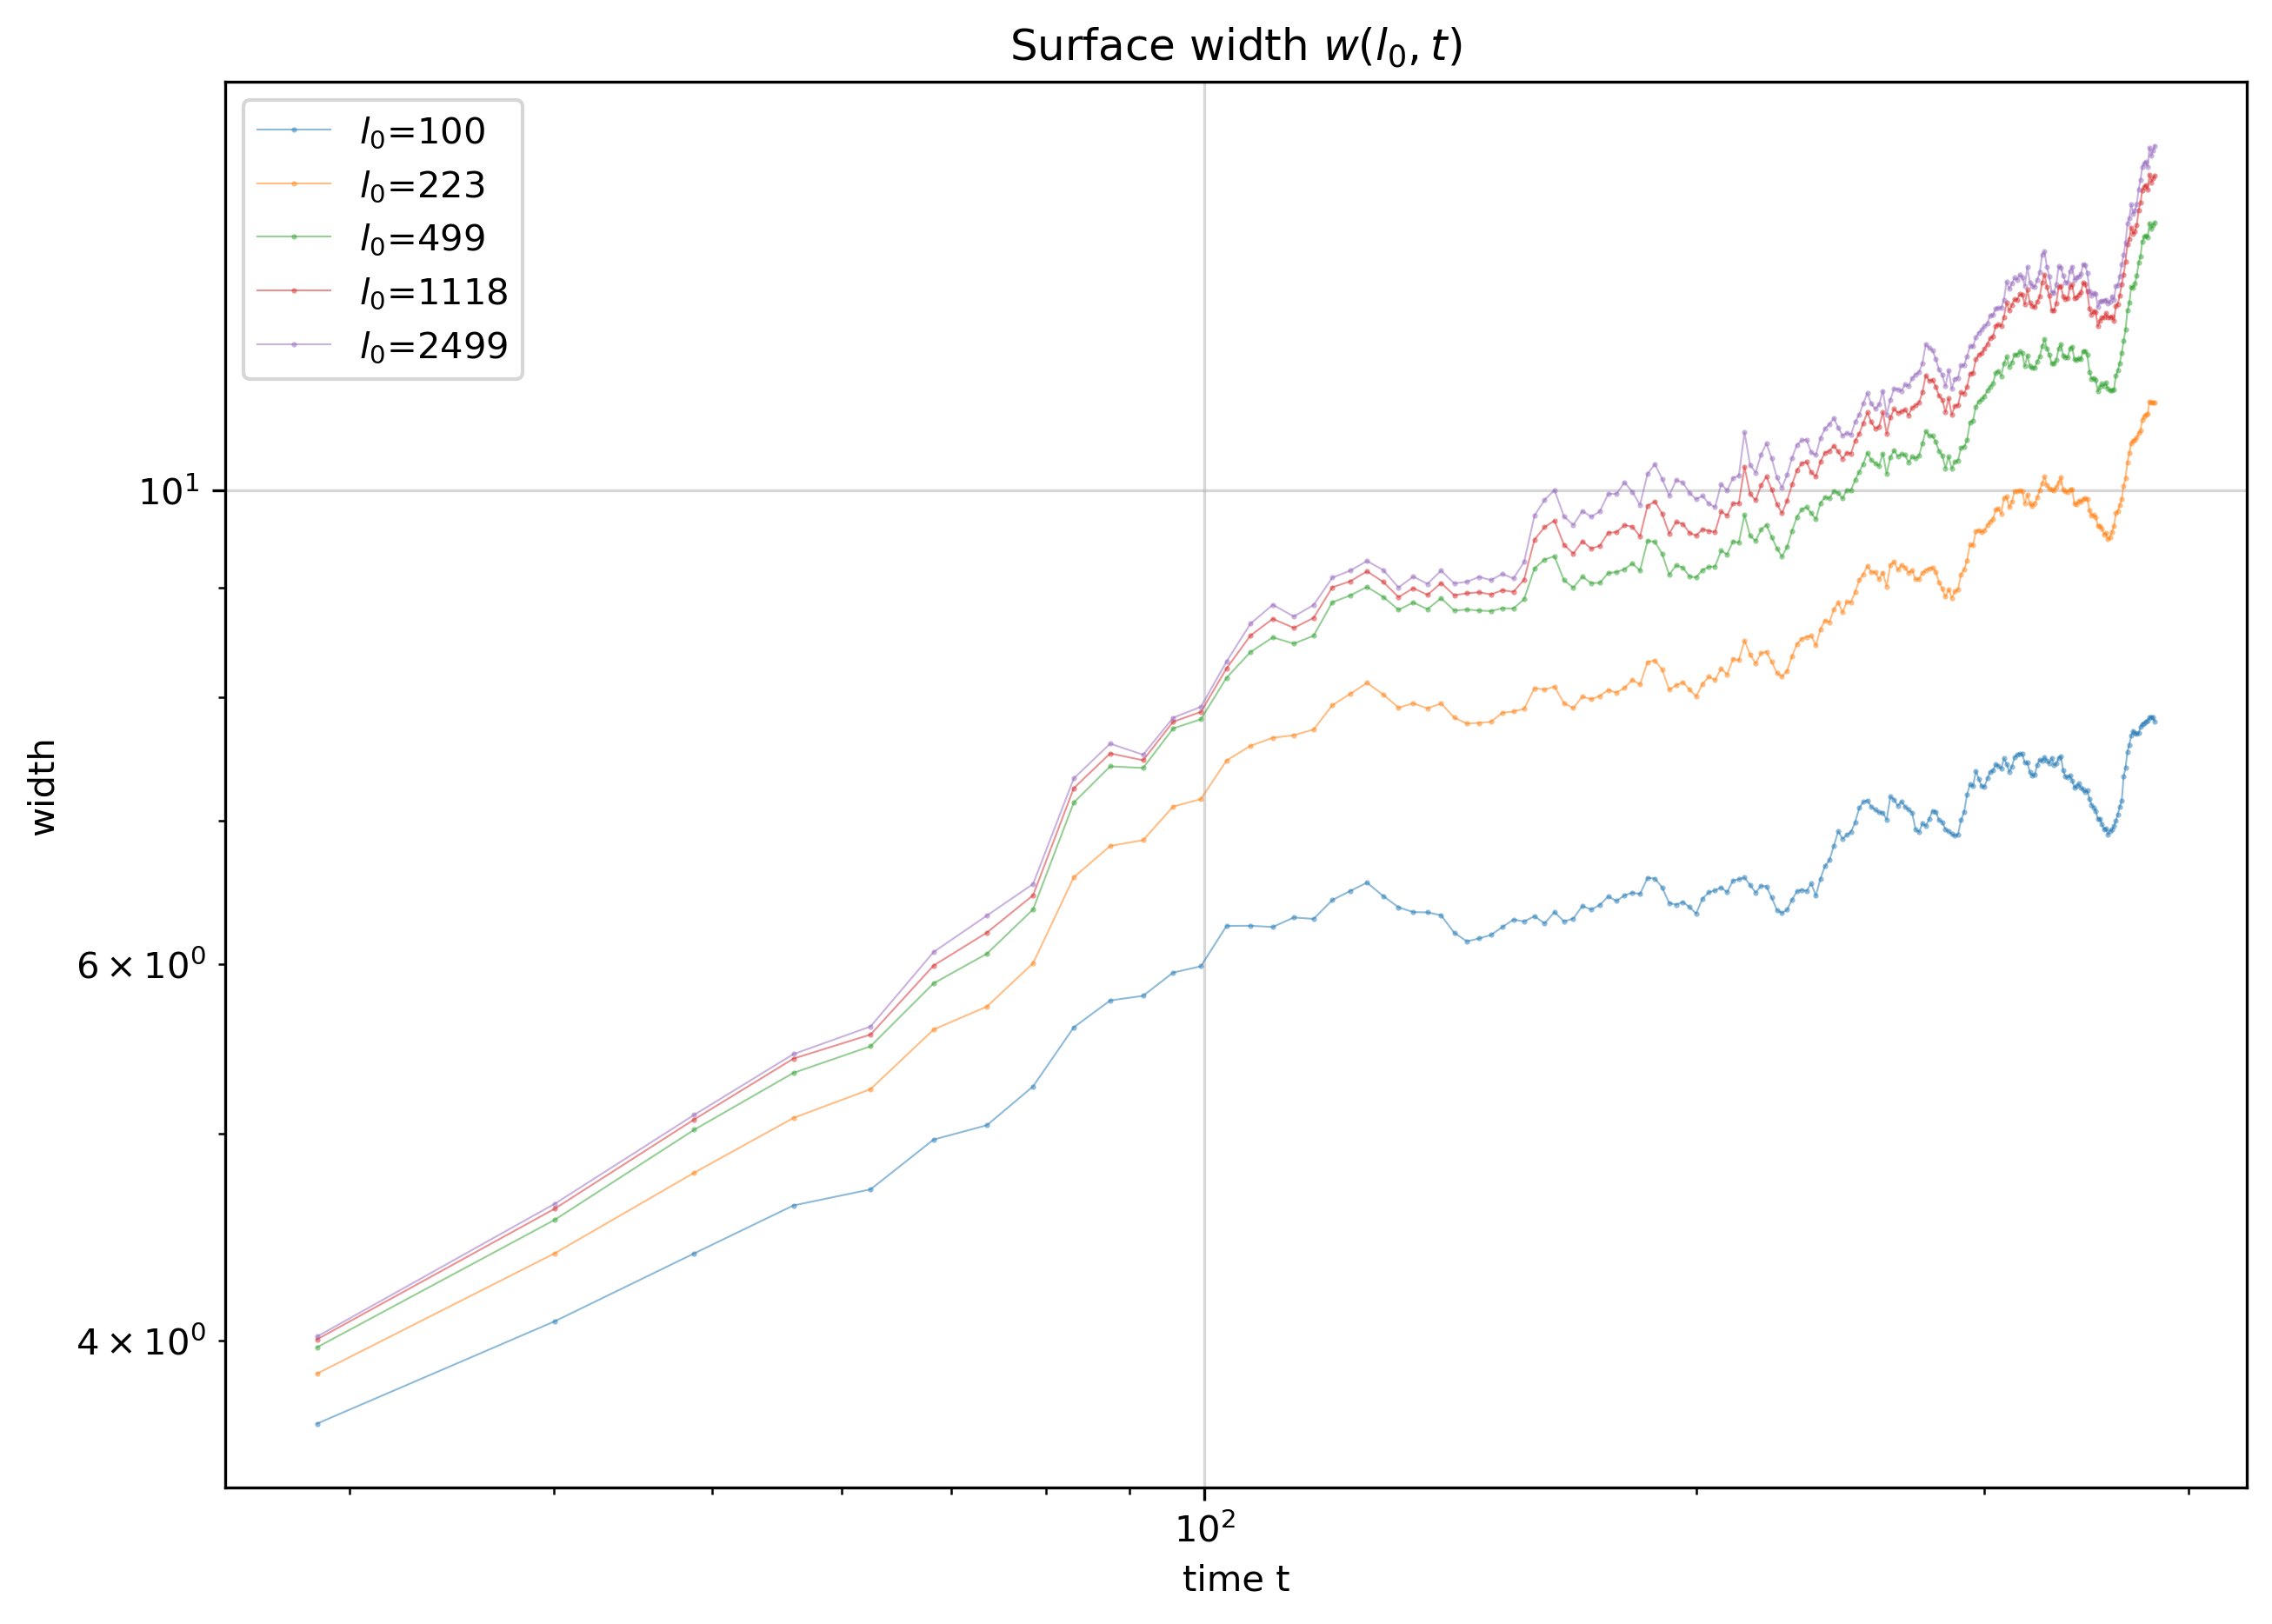

In [7]:
# ============================================================
# plot w(l_0, t) as a function of time
# ============================================================
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_0s = sim_run.ls
t = obs['t']
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    log_log_slopes.append(fit_loglog_slope(t, w_l_0))
    ax.plot(t, w_l_0, lw=0.5, label=f"$l_0$={l_0}", alpha=0.5, marker='o', markersize=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("width")
ax.set_title("Surface width $w(l_0, t)$")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

## Notes

The median interface height scales as $h(t) \sim \sqrt{t}$ where $t$ is the number of steps or attempts. In group meeting, it was mentioned that time slows down as you fill up your lattice. Your chances of a successsful jump basically scales inversely proportional to the remaining number of lattice sites. (Maybe I can do a rough calculation of what this is like. I also need to read the SI from Hallatschek's paper to see how he implemented the algorithm.) 

I need to check the code again for computing this "surface roughness"  

Additionally I need to make sure that my "rate" at which I'm populating the lattice sites stays constant, which is achieved by: 
1) Modifying the code to sample from ANY site on the L by L lattice 
2) Modifying the time step to be inversely proportional to the number of occupied sites. 

When modified by the wall time, we should expect this front to grow linearly in time.

## Debugging

In [ ]:

# ============================================================
# Tests for extract_surface_width_standard_deviation
# ============================================================
import traceback

rng = np.random.default_rng(0)

# --- Minimal fake surface for a known answer ---
# L=8, surface sites in a flat band at y=5 (all columns occupied once)
L_test = 8
surface_flat = np.zeros((20, L_test), dtype=np.uint8)
surface_flat[5, :] = 1   # perfectly flat -> SD should be 0 for every window

# Bug 1: syntax error (ßß) — the class definition itself would fail to compile.
# Demonstrated by checking the method actually exists:
sim_test = StochasticGrowthStripGeometry(L=L_test, mu=3.0, seed=0)
print("Bug 1 check – class instantiates (syntax error would prevent this):", type(sim_test))

# Bug 2: avg_y2_window uses `sum_y2_col` (shape 2L,) instead of `sum_y2_window`
# → numpy raises AxisError because sum_y2_col is 1-D, can't sum on axis=1
print("\nBug 2 check – calling extract_surface_width_standard_deviation on flat surface:")
try:
    w = sim_test.extract_surface_width_standard_deviation(surface_flat, l_min=2, l_max=4)
    print("  Returned (no crash):", w)
    print("  Expected all zeros (flat surface → SD=0):", np.allclose(w, 0))
except Exception as e:
    print(f"  CRASHED with {type(e).__name__}: {e}")

# Bug 3: `SDy = np.sqrt(SSy)` is computed but never used;
#         widths[i] = np.mean(np.sqrt(SSy)) recomputes the same thing.
#         Minor redundancy — not a crash, but wasted work.
print("\nBug 3 check (redundant SDy variable): inspect source — SDy is computed but widths[i] calls np.sqrt(SSy) again.")
import inspect
src = inspect.getsource(sim_test.extract_surface_width_standard_deviation)
has_SDy_assigned = "SDy = np.sqrt(SSy)" in src
used_SDy         = "np.mean(SDy)" in src
print(f"  SDy assigned: {has_SDy_assigned}, SDy used in mean: {used_SDy}  (should be True/True after fix)")


In [ ]:
plt.imshow(sim.grid[:50, :10], origin="lower")

In [ ]:
surf = sim.extract_surface()
plt.imshow(surf[:50, :10], origin="lower")

In [ ]:
y_idx, x_idx = np.where(surf[:50, :10] > 0)
n_col = np.bincount(x_idx)
std_true = np.std(y_idx)
y_col = np.bincount(x_idx, y_idx)
y2_col = np.bincount(x_idx, y_idx**2)
mean_y = np.sum(y_col) / np.sum(n_col)
mean_y2 = np.sum(y2_col) / np.sum(n_col)
std_alg = np.sqrt(mean_y2 - mean_y**2)
print(std_true, std_alg) # check

In [7]:
@numba.njit(cache=True)
def _sd_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    ls: np.ndarray,
) -> np.ndarray:
    """Incremental sliding-window SD kernel, compiled by Numba.

    For each window width l, maintains three running sums (n, Σy, Σy²) and
    updates them in O(1) as the window shifts one column right:
        remove exiting column x, add entering column (x + l) % L.

    This is O(L) per l value vs the numpy version's O(L·l) from
    sliding_window_view + sum(axis=1), and allocates no large intermediates.

    Args:
        n_col:      Per-column surface-site counts,  shape (L,).
        sum_y_col:  Per-column Σy,                   shape (L,).
        sum_y2_col: Per-column Σy²,                  shape (L,).
        ls:         1-D int64 array of window widths.

    Returns:
        Array of shape (len(ls),) with mean SD per window width.
    """
    L = n_col.shape[0]
    widths = np.empty(ls.shape[0])

    for li in range(ls.shape[0]):
        l = ls[li]

        # Initialise first window [0, l)
        n_w = 0.0; sy = 0.0; sy2 = 0.0
        for k in range(l):
            n_w  += n_col[k]
            sy   += sum_y_col[k]
            sy2  += sum_y2_col[k]

        total_sd = 0.0
        valid = 0

        for x in range(L):
            if n_w > 0.0:
                mean_y = sy / n_w
                var = sy2 / n_w - mean_y * mean_y
                if var < 0.0:
                    var = 0.0
                total_sd += var ** 0.5
                valid += 1

            # O(1) slide: remove column x, add column (x + l) % L
            x_add = (x + l) % L
            n_w  += n_col[x_add]  - n_col[x]
            sy   += sum_y_col[x_add]  - sum_y_col[x]
            sy2  += sum_y2_col[x_add] - sum_y2_col[x]

        widths[li] = total_sd / valid if valid > 0 else np.nan

    return widths


def _extract_surface_width_sd_fast(self, surface: np.ndarray, ls) -> np.ndarray:
    """Fast drop-in for extract_surface_width_standard_deviation.

    Delegates to _sd_width_kernel (Numba JIT). O(L) per window width instead
    of O(L·l) — no large intermediate arrays. First call triggers JIT compilation.
    """
    L = self.L
    ys_idx, xs_idx = np.where(surface > 0)
    ys_f       = ys_idx.astype(np.float64)
    n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
    sum_y_col  = np.bincount(xs_idx, weights=ys_f,       minlength=L)
    sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2,  minlength=L)
    return _sd_width_kernel(n_col, sum_y_col, sum_y2_col, np.asarray(ls, dtype=np.int64))

StochasticGrowthStripGeometry.extract_surface_width_sd_fast = _extract_surface_width_sd_fast


# ── Correctness + timing check ───────────────────────────────────────────────
import time

sim_bench = StochasticGrowthStripGeometry(L=2_000, mu=4.0, seed=7)
for _ in range(2000):
    sim_bench.step()
surf_bench = sim_bench.extract_surface()
ls_bench   = list(range(50, 2_001))

# Warm-up JIT
_ = sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)

w_old = sim_bench.extract_surface_width_standard_deviation(surf_bench, ls_bench)
w_new = sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)
print("Results match:", np.allclose(w_old, w_new, rtol=1e-10))

N = 5
t0 = time.perf_counter()
for _ in range(N):
    sim_bench.extract_surface_width_standard_deviation(surf_bench, ls_bench)
t_old = (time.perf_counter() - t0) / N

t0 = time.perf_counter()
for _ in range(N):
    sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)
t_new = (time.perf_counter() - t0) / N

print(f"Old: {t_old*1e3:.2f} ms  |  New: {t_new*1e3:.2f} ms  |  Speedup: {t_old/t_new:.1f}x")


Results match: True
Old: 1291.52 ms  |  New: 85.97 ms  |  Speedup: 15.0x
